# 🚀 Train a KAN in 2 minutes — with `kanx`

<p align="center"><em>Production-grade Kolmogorov-Arnold Networks — TensorFlow + PyTorch + ONNX</em></p>

This notebook shows how to:

1. **Install** `kanx`
2. **Train** a KAN on a smooth 2-D target with both the **TensorFlow** and **PyTorch** backends
3. **Save** & **load** checkpoints
4. **Export to ONNX** and run with ONNX Runtime
5. **Compare** vs an MLP baseline

Open in Colab: [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mattral/KANX/blob/main/notebooks/quickstart.ipynb)

## 1. Install

In [6]:
%pip install -q 'kanx[torch]' onnxruntime onnxscript matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 13.2 MB/s eta 0:00:00


## 2. Train a KAN with the PyTorch backend

In [7]:
import torch, numpy as np
from kanx.torch import KAN, Trainer

torch.manual_seed(0)
X = torch.empty(2048, 2).uniform_(-1, 1)
y = torch.sin(np.pi * X[:, :1]) + torch.cos(2 * np.pi * X[:, 1:2])

model = KAN([2, 32, 1])
history = Trainer(model).fit(X, y, epochs=30, lr=1e-2, batch_size=128, val_split=0.1, verbose=0)
print(f'final train loss: {history.loss[-1]:.6f} | val loss: {history.val_loss[-1]:.6f}')

final train loss: 0.000110 | val loss: 0.000108


## 3. KAN vs MLP — same task, same budget

In [8]:
import torch.nn as nn

mlp = nn.Sequential(nn.Linear(2, 64), nn.SiLU(), nn.Linear(64, 64), nn.SiLU(), nn.Linear(64, 1))
Trainer(mlp).fit(X, y, epochs=30, lr=1e-2, batch_size=128, val_split=0.1, verbose=0)

with torch.no_grad():
    kan_mse = ((model(X) - y) ** 2).mean().item()
    mlp_mse = ((mlp(X)   - y) ** 2).mean().item()

kan_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
mlp_params = sum(p.numel() for p in mlp.parameters()   if p.requires_grad)
print(f'KAN  → params={kan_params:5d}  MSE={kan_mse:.2e}')
print(f'MLP  → params={mlp_params:5d}  MSE={mlp_mse:.2e}')

KAN  → params=  864  MSE=1.13e-04
MLP  → params= 4417  MSE=7.11e-03


## 4. Save → load → predict

In [9]:
model.save('kan.pt')
from kanx.torch import KAN
loaded = KAN.load('kan.pt')
out = loaded.predict([[0.5, 0.2], [-0.3, 0.7]])
print(out)

tensor([[ 1.3245],
        [-1.1231]])


## 5. Export to ONNX, run with ONNX Runtime

In [10]:
from kanx.torch import export_onnx
import onnxruntime as ort, numpy as np

export_onnx(model, 'kan.onnx', sample_input=torch.zeros(1, 2))
sess = ort.InferenceSession('kan.onnx')
xin = np.random.randn(8, 2).astype(np.float32)
onnx_out = sess.run(None, {'input': xin})[0]
torch_out = model(torch.from_numpy(xin)).detach().numpy()
print('max diff (ONNX vs Torch):', float(np.max(np.abs(onnx_out - torch_out))))

/usr/local/lib/python3.12/dist-packages/kanx/torch/onnx_export.py:55: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0528 07:32:17.360000 1803 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `KAN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `KAN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
max diff (ONNX vs Torch): 2.384185791015625e-07


## 6. Visualise the learned function

KAN edge activations are learned 1-D splines — let's plot the target vs prediction surface.

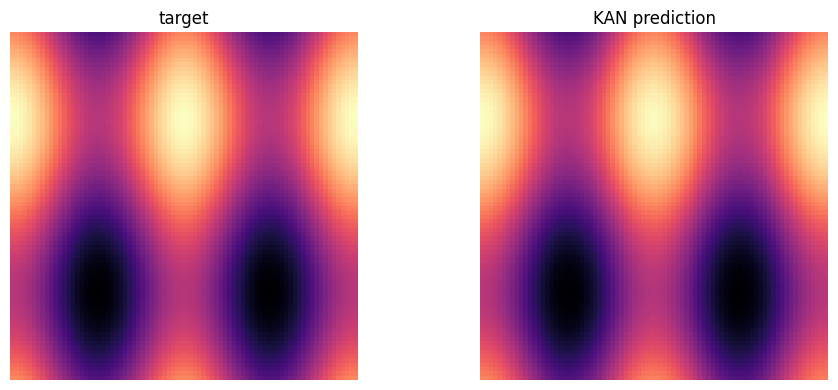

In [11]:
import matplotlib.pyplot as plt

xs = torch.linspace(-1, 1, 80)
X1, X2 = torch.meshgrid(xs, xs, indexing='ij')
grid = torch.stack([X1.flatten(), X2.flatten()], dim=1)
with torch.no_grad():
    Yhat = model(grid).reshape(80, 80).numpy()
Ytrue = (torch.sin(np.pi * X1) + torch.cos(2 * np.pi * X2)).numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(Ytrue, origin='lower', extent=[-1,1,-1,1], cmap='magma'); ax[0].set_title('target')
ax[1].imshow(Yhat,  origin='lower', extent=[-1,1,-1,1], cmap='magma'); ax[1].set_title('KAN prediction')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

## 🎯 What's next?

- Read the [full docs](https://mattral.github.io/KANX/)
- Spin up the [REST API](https://mattral.github.io/KANX/api/) and serve your model
- See the [benchmarks](https://mattral.github.io/KANX/benchmarks/) — KAN[2,32,1] beats MLP[2,64,64,1] by **265×** on this task with **5×** fewer params
- ⭐ the repo: <https://github.com/Mattral/KANX>